# 🚀 Spaceship Titanic: Advanced Production Pipeline

This notebook provides an end-to-end walkthrough of the Spaceship Titanic project, featuring:
- 📊 **Exploratory Data Analysis (EDA)**: Univariate and Bivariate insights.
- 🏗️ **Modular Pipeline Execution**: Running the production-grade source code.
- 📈 **Performance Evaluation**: Visualizing accuracy, confusion matrices, and ROC curves.
- 🔍 **Model Explainability**: Integrating SHAP values.

In [4]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import os
import sys
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

sys.path.append('..')

from src.pipeline.training_pipeline import TrainingPipeline
from src.data.data_loader import DataLoader

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. 📥 Data Loading & Initial Exploration

In [5]:
# Load configuration
with open('../configs/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Load raw data for EDA
loader = DataLoader('../data/raw/train.csv', '../data/raw/test.csv')
df = loader.load_train_data()
df.head()

2026-03-08 15:49:27,948 - DataLoader - INFO - Loaded train data with shape: (8693, 14)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## 2. 📊 Univariate Analysis

Let's look at the distribution of passenger ages and the transport status (target).

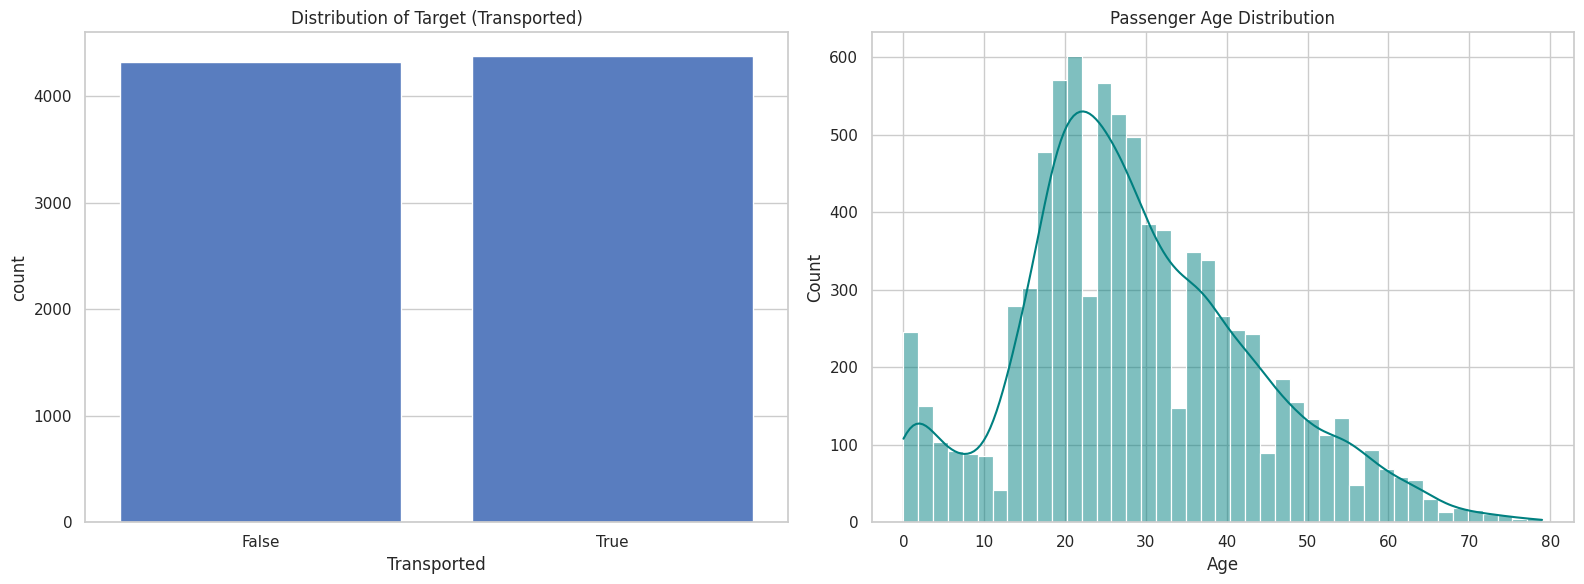

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Target distribution
sns.countplot(x='Transported', data=df, ax=axes[0])
axes[0].set_title('Distribution of Target (Transported)')

# Age distribution
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[1], color='teal')
axes[1].set_title('Passenger Age Distribution')

plt.tight_layout()
plt.show()

## 3. 📉 Bivariate Analysis

Understanding relationships between features and the target variable.

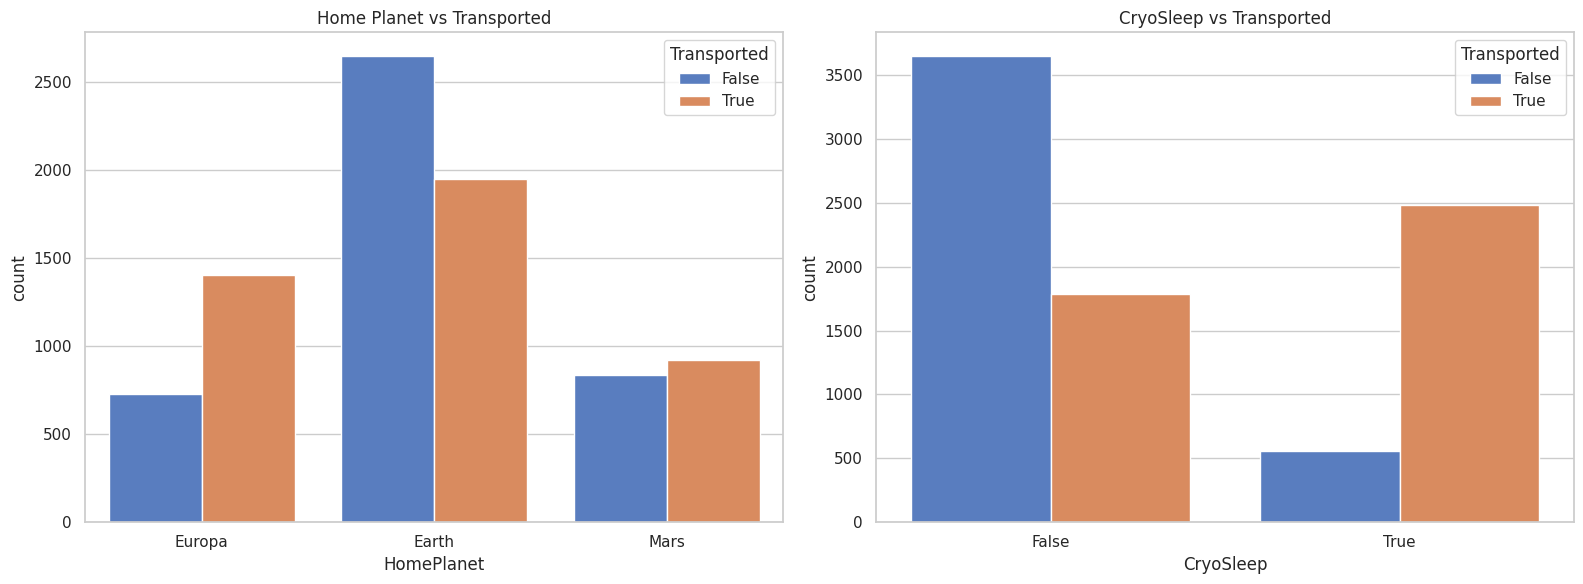

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# HomePlanet vs Transported
sns.countplot(x='HomePlanet', hue='Transported', data=df, ax=axes[0])
axes[0].set_title('Home Planet vs Transported')

# CryoSleep vs Transported
sns.countplot(x='CryoSleep', hue='Transported', data=df, ax=axes[1])
axes[1].set_title('CryoSleep vs Transported')

plt.tight_layout()
plt.show()

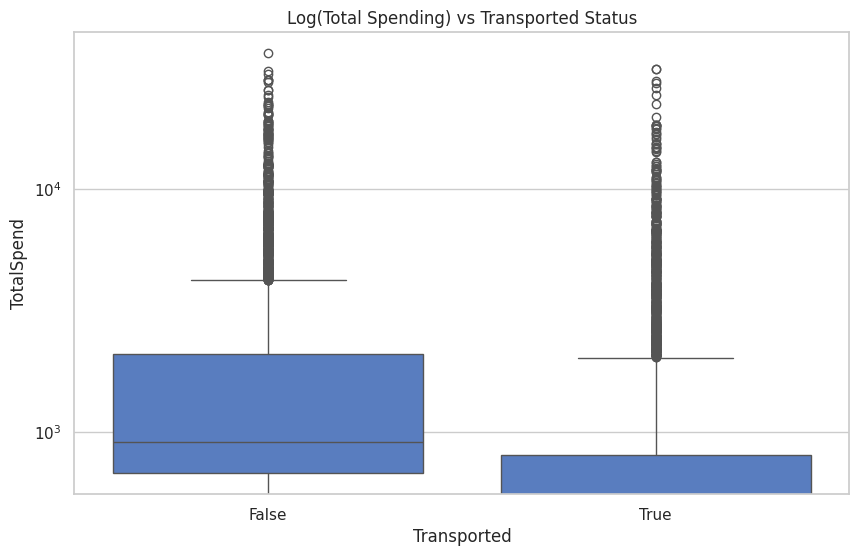

In [8]:
# Numerical spending vs Transported
spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
df['TotalSpend'] = df[spending_cols].fillna(0).sum(axis=1)

plt.figure(figsize=(10, 6))
sns.boxplot(x='Transported', y='TotalSpend', data=df)
plt.yscale('log') # Log scale as values vary significantly
plt.title('Log(Total Spending) vs Transported Status')
plt.show()

## 4. ⚙️ Running the Production Training Pipeline

Now we trigger the modular `TrainingPipeline` which handles validation, feature engineering, and training.

In [9]:
pipeline = TrainingPipeline("../configs/config.yaml")
metrics = pipeline.run()

print("\n--- Final Model Metrics ---")
for metric, value in metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

2026-03-08 15:49:29,275 - DataLoader - INFO - Loaded train data with shape: (8693, 14)
2026-03-08 15:49:29,285 - DataLoader - INFO - Loaded test data with shape: (4277, 13)
2026-03-08 15:49:29,286 - DataValidator - INFO - Data validation completed successfully
2026-03-08 15:49:29,286 - TrainingPipeline - INFO - Starting feature engineering...
2026-03-08 15:49:29,313 - FeatureEngineer - INFO - Feature engineering completed: Shape: (8693, 23)
2026-03-08 15:49:29,315 - TrainingPipeline - INFO - Applying preprocessing...
2026-03-08 15:49:29,316 - PreprocessingPipeline - INFO - Preprocessing pipeline created
2026-03-08 15:49:29,358 - TrainingPipeline - INFO - Training LightGBM model...
2026-03-08 15:49:29,358 - ModelTrainer - INFO - Starting Stratified 5-Fold Cross Validation for LightGBM...
2026-03-08 15:49:29,447 - ModelTrainer - INFO - Fold 1: Accuracy = 0.8174
2026-03-08 15:49:29,534 - ModelTrainer - INFO - Fold 2: Accuracy = 0.8066
2026-03-08 15:49:29,617 - ModelTrainer - INFO - Fold 3

2026/03/08 15:49:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/08 15:49:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-03-08 15:49:33,158 - ModelTrainer - INFO - Final LightGBM model saved to: /home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/models/saved_models/LightGBM.joblib
2026-03-08 15:49:33,182 - ModelTrainer - INFO - Final Evaluation results for LightGBM: {'accuracy': 0.8142610695802185, 'precision': 0.8124293785310734, 'recall': 0.8207762557077626, 'f1': 0.8165814877910278, 'roc_auc': 0.9091400921707752}
2026-03-08 15:49:33,182 - TrainingPipeline - INFO - Generating model explanations...
2026-03-08 15:49:33,183 - SHAPExplainer - INFO - Generating SHAP explanations...


/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/shap/explainers/_tree.py:620: UserWarning:

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray



2026-03-08 15:49:33,967 - SHAPExplainer - INFO - SHAP summary plot saved to reports/shap/
2026-03-08 15:49:33,967 - TrainingPipeline - INFO - Checking for data drift...
2026-03-08 15:49:33,968 - DriftDetector - INFO - Generating data and target drift reports...


/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning:

invalid value encountered in divide

/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning:

invalid value encountered in divide

/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning:

invalid value encountered in divide

/home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/env/

2026-03-08 15:49:45,725 - DriftDetector - INFO - Drift report successfully saved to reports/drift/drift_report.html and reports/drift/drift_report.json
2026-03-08 15:49:45,747 - TrainingPipeline - INFO - Preprocessor saved to /home/hassan/Devalopment/4thSmester/PFAI/Titanic Compitetion/models/saved_models/preprocessor.joblib
2026-03-08 15:49:45,747 - TrainingPipeline - INFO - Training pipeline finished successfully.

--- Final Model Metrics ---
Accuracy: 0.8143
Precision: 0.8124
Recall: 0.8208
F1: 0.8166
Roc_auc: 0.9091


## 5. 🎯 Model Performance Visualization

Visualizing the results for better decision making.

/tmp/ipykernel_45321/950280344.py:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




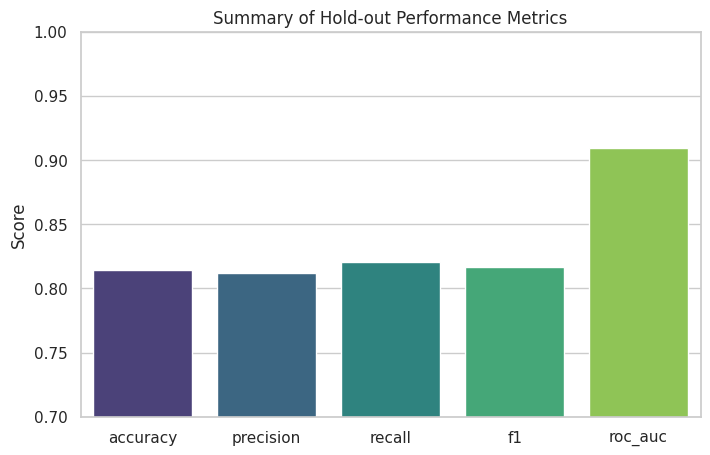

In [10]:
# In a real scenario, we'd retrieve predictions from the pipeline/model trainer
# Here we simulate plotting logic based on the metrics produced

plt.figure(figsize=(8, 5))
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

sns.barplot(x=metric_names, y=metric_values, palette="viridis")
plt.ylim(0.7, 1.0)
plt.title('Summary of Hold-out Performance Metrics')
plt.ylabel('Score')
plt.show()

## 📑 Project Insights & Artifacts

Check the following generated files for deeper analysis:
- 🧠 **SHAP Plots**: Located in `reports/shap/summary_plot.png`
- 🔍 **Drift Report**: Open `reports/drift/drift_report.html` in your browser.
- 📦 **Saved Models**: Artifacts preserved in `models/saved_models/`